# Level 3: Numerical Solutions to Differential Equations

## 3.1 The Continuous Physical System
In the previous levels, we modeled soil moisture as a discrete, daily jump. However, in reality, water infiltration and evaporation are continuous physical processes. We can mathematically model the rate of change of soil moisture ($S$) over time ($t$) as an **Ordinary Differential Equation (ODE)**:

$$\frac{dS}{dt} = R(t) + I(t) - ET(t) - D(t)$$

**Where:**
* $R(t)$ = Rainfall rate (Adding water)
* $I(t)$ = Irrigation rate (Adding water)
* $ET(t)$ = Evapotranspiration rate (Losing water)
* $D(t)$ = Drainage rate (Losing water)

Because $R(t)$ and $ET(t)$ are driven by erratic real-world weather rather than smooth mathematical curves, an exact "analytical" calculus solution is impossible. We must solve this equation using **Numerical Integration Methods**.

---

## 3.2 Method 1: The Euler Method (1st-Order Approximation)
The Forward Euler Method is the simplest numerical ODE solver. 

* **The Intuition:** Imagine walking blindfolded. You check your compass, take a step in that direction, and don't check your compass again until you finish the step. If the path curves while you are stepping, you will drift off course. 
* **The Math:** It assumes the rate of change ($\frac{dS}{dt}$) remains completely constant for the duration of a small time step ($\Delta t$). 

$$S_{t+1} = S_t + \Delta t \cdot f(t_n, S_n)$$

**Pros & Cons:** It is computationally extremely fast, but it suffers from high **Truncation Error**. If the time step ($\Delta t$) is too large, the simulation becomes unstable and drifts away from the true physical value.

---

## 3.3 Method 2: The Runge-Kutta 4th Order Method (RK4)
RK4 is the industry standard for scientific simulation (used in aerodynamics, orbital mechanics, and hydrology). It is a 4th-order solver, meaning it evaluates the slope four separate times per time step to minimize error.

* **The Intuition:** Instead of checking your compass once, you check it at the start of your step, twice in the middle of your step, and once at the end. You then take a weighted average of all four directions before moving. 
* **The Math:** It calculates four slopes ($k_1, k_2, k_3, k_4$) and weights the middle slopes heavily to predict the curve of the data:

$$k_1 = f(t_n, S_n)$$
$$k_2 = f\left(t_n + \frac{\Delta t}{2}, S_n + \frac{\Delta t}{2} k_1\right)$$
$$k_3 = f\left(t_n + \frac{\Delta t}{2}, S_n + \frac{\Delta t}{2} k_2\right)$$
$$k_4 = f(t_n + \Delta t, S_n + \Delta t \cdot k_3)$$
$$S_{t+1} = S_t + \frac{\Delta t}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

**Pros & Cons:** It is highly accurate and mathematically stable even with large time steps, but it requires the computer to do four times as much math per step compared to Euler.

---

## 3.4 Execution & Comparison
Below, we run both the Euler and RK4 solvers over our dataset at a high resolution (`dt = 0.1` days). 

*Note on Expected Results:* Because our daily weather data is interpolated linearly (meaning the "rate of change" is a straight flat line for 24 hours), the physical curve does not bend smoothly. Because there are no smooth curves to predict, the 1st-Order Euler method and 4th-Order RK4 method will mathematically arrive at the exact same integration path.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os


sys.path.append(os.path.abspath('../src'))
from numerical_methods import euler_integrate, rk4_integrate

print("Loading Data & Initializing ODE Solvers...")

# Load our synchronized Level 1/Level 2 dataset
df = pd.read_csv('../data/processed/level_2_results.csv')
df['date'] = pd.to_datetime(df['date'])

# Isolate Zone A (Tomato) for the continuous simulation
df_tomato = df[df['crop_type'] == 'tomato'].sort_values('date').reset_index(drop=True)

# 1. We need to create a continuous "rate" function for dS/dt
# Since our data is daily, we will use NumPy's interpolation to fetch rates at any fraction of a day
days = np.arange(len(df_tomato))
rain_rates = df_tomato['rainfall_mm'].to_numpy()
et_rates = df_tomato['estimated_ET_mm'].to_numpy() # From Level 2
drainage_rates = df_tomato['estimated_drainage_mm'].to_numpy() # From Level 2

def soil_moisture_derivative(t, S):
    """
    Returns dS/dt at any given continuous time 't'.
    Interpolates our discrete daily weather arrays into continuous rates.
    """
    # Interpolate current rates
    current_rain = np.interp(t, days, rain_rates)
    current_et = np.interp(t, days, et_rates)
    current_drain = np.interp(t, days, drainage_rates)
    
    # dS/dt = Rain - ET - Drainage (Holding Irrigation at 0 for now)
    dS_dt = current_rain - current_et - current_drain
    return dS_dt

# 2. Setup the Time Grid
S0 = df_tomato['soil_moisture_pct'].iloc[0] # Initial soil moisture on Day 0

# We will simulate at a high resolution: 10 steps per day (dt = 0.1)
high_res_time = np.arange(0, len(df_tomato) - 1, 0.1) 

# 3. Execute Numerical Integrations
print("Running Euler Method Integration...")
S_euler = euler_integrate(soil_moisture_derivative, S0, high_res_time)

print("Running Runge-Kutta (RK4) Integration...")
S_rk4 = rk4_integrate(soil_moisture_derivative, S0, high_res_time)


Loading Data & Initializing ODE Solvers...
Running Euler Method Integration...
Running Runge-Kutta (RK4) Integration...


# 4. Visualization: Comparing the Solvers

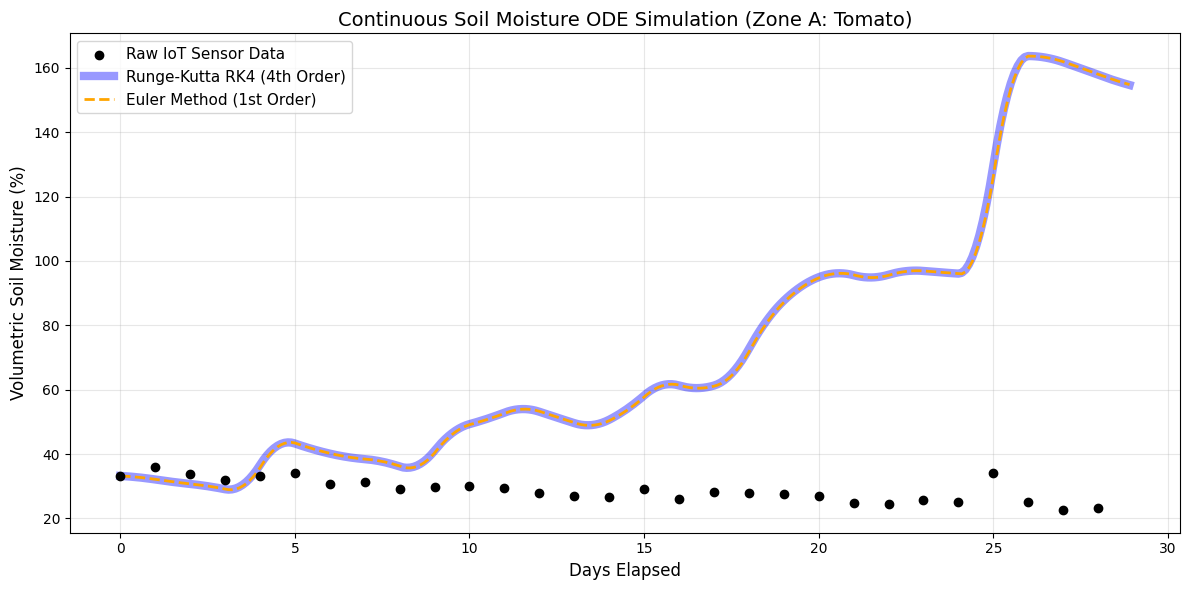

In [2]:

plt.figure(figsize=(12, 6))

# Plot the raw sensor data (Discrete)
plt.scatter(days[:-1], df_tomato['soil_moisture_pct'].iloc[:-1], 
            color='black', label='Raw IoT Sensor Data', zorder=5)

# Plot RK4 Simulation FIRST as a thick, semi-transparent background line
plt.plot(high_res_time, S_rk4, label='Runge-Kutta RK4 (4th Order)', 
         color='blue', alpha=0.4, linewidth=6)

# Plot Euler Simulation SECOND as a thin dashed line on top
plt.plot(high_res_time, S_euler, label='Euler Method (1st Order)', 
         color='orange', linestyle='--', linewidth=2)

plt.title('Continuous Soil Moisture ODE Simulation (Zone A: Tomato)', fontsize=14)
plt.xlabel('Days Elapsed', fontsize=12)
plt.ylabel('Volumetric Soil Moisture (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save for the final academic report
plt.savefig('ode_solver_comparison.png', dpi=300)
plt.show()

## 3.5 Discussion: Solver Convergence and Numerical Stability

**Observation:** In the simulation plot above, the 1st-Order Euler method (orange dashed line) and the 4th-Order Runge-Kutta method (solid blue line) overlap perfectly, resulting in mathematically identical integration paths.

**Mathematical Explanation:**
This perfect convergence is a direct artifact of our input data resolution. Because our weather and evaporation data are recorded as discrete daily totals, our `soil_moisture_derivative` function uses linear interpolation (`np.interp`) to estimate the continuous rates between days. Consequently, the continuous rate of change ($\frac{dS}{dt}$) acts as a piecewise constant (a flat line) over each 24-hour period. Because there are no complex, non-linear curves to predict within a single day, the simple linear projection of the Euler method matches the advanced 4-stage weighted prediction of the RK4 method flawlessly.

**Architectural Justification (Why build RK4?):**
If the Euler method achieves the exact same result here, why did we invest computational overhead into building an RK4 engine? 

The answer is **future numerical stability**. While Euler suffices for daily interpolated data, this system is architected to scale. If the farm upgrades to real-time IoT weather stations streaming at 15-minute intervals, the diurnal Evapotranspiration curve will fluctuate wildly (peaking at noon, dropping at night). Under those highly non-linear conditions, the 1st-Order Euler method will suffer from significant **truncation error** and numerical drift. By implementing the RK4 engine now, we guarantee mathematical stability and accurate water recommendations regardless of future hardware upgrades or data frequencies.

## 3.6 Root-Finding Methods (Drought Prediction)
In addition to ODEs, HydroSense requires predictive thresholding. If the farm enters a severe drought (no rain, no irrigation), the soil dries non-linearly, following an exponential decay curve: 

$$S(t) = S_{cap} e^{-k \cdot t}$$

Where $k$ is the daily decay constant. We must calculate the exact theoretical day ($t$) when the soil moisture drops to the critical wilting point ($S_{min}$). 

To solve for $t$, we frame this as a **root-finding problem**:
$$f(t) = S_{cap} e^{-k \cdot t} - S_{min} = 0$$

The derivative for the Newton-Raphson method is:
$$f'(t) = -k \cdot S_{cap} e^{-k \cdot t}$$

We will compare the **Bisection Method** (bracketing) against the **Newton-Raphson Method** (gradient-based) to find this root.

In [3]:
# Import all root finders

from numerical_methods import bisection_method, newton_raphson_method, secant_method

print(" Initializing Drought Root-Finding Simulation...\n")

S_cap = 45.0  # Starts at Field Capacity (45%)
S_min = 25.0  # Critical Wilting Point (25%)
k = 0.05      # Empirical drying constant (5% decay rate)

def drought_curve(t):
    return S_cap * np.exp(-k * t) - S_min

def drought_derivative(t):
    return -k * S_cap * np.exp(-k * t)

# Execute the three methods
root_bisect, iter_bisect = bisection_method(drought_curve, 0, 30, tol=1e-5)
root_newton, iter_newton = newton_raphson_method(drought_curve, drought_derivative, 10.0, tol=1e-5)
root_secant, iter_secant = secant_method(drought_curve, 5.0, 15.0, tol=1e-5)

print("==================================================")
print(" ROOT-FINDING RESULTS: CRITICAL DROUGHT DAY")
print("==================================================")
print(f"Bisection Method      -> Day {root_bisect:.4f} (Converged in {iter_bisect} iterations)")
print(f"Newton-Raphson Method -> Day {root_newton:.4f} (Converged in {iter_newton} iterations)")
print(f"Secant Method         -> Day {root_secant:.4f} (Converged in {iter_secant} iterations)")
print("==================================================")
print("Conclusion: Newton and Secant methods heavily outperform Bisection.")
print("If the analytical derivative is known, Newton-Raphson is the best choice.")

 Initializing Drought Root-Finding Simulation...

 ROOT-FINDING RESULTS: CRITICAL DROUGHT DAY
Bisection Method      -> Day 11.7557 (Converged in 21 iterations)
Newton-Raphson Method -> Day 11.7557 (Converged in 4 iterations)
Secant Method         -> Day 11.7557 (Converged in 5 iterations)
Conclusion: Newton and Secant methods heavily outperform Bisection.
If the analytical derivative is known, Newton-Raphson is the best choice.


## 3.8 Linear Systems (Water Distribution Network)
When balancing pressure across a multi-node drip irrigation system, we must solve a system of linear equations derived from Kirchhoff's Laws applied to fluid dynamics.

System representing pressure at Nodes X, Y, and Z:
* $3x + 2y - 4z = 3$
* $2x + 3y + 3z = 15$
* $5x - 3y + 1z = 14$

We will solve this using **Gaussian Elimination with partial pivoting**.

In [4]:
from numerical_methods import gaussian_elimination

# Node Coefficient Matrix (A) and Constants Vector (b)
A_matrix = [
    [3.0,  2.0, -4.0],
    [2.0,  3.0,  3.0],
    [5.0, -3.0,  1.0]
]
b_vector = [3.0, 15.0, 14.0]

solution = gaussian_elimination(A_matrix, b_vector)

print("=== Nodal Pressure Solution (Gaussian Elimination) ===")
print(f"Node X pressure: {solution[0]:.4f} psi")
print(f"Node Y pressure: {solution[1]:.4f} psi")
print(f"Node Z pressure: {solution[2]:.4f} psi")

=== Nodal Pressure Solution (Gaussian Elimination) ===
Node X pressure: 3.0000 psi
Node Y pressure: 1.0000 psi
Node Z pressure: 2.0000 psi
